In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan approval data.csv")
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [5]:
df.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.0,Salaried,47.0,Married,2.0,636.0,4.0,NaN,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,NaN,No
8,9.0,16423.0,NaN,Salaried,54.0,Married,1.0,729.0,0.0,0.59,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.0,Contract,35.0,Single,3.0,726.0,1.0,NaN,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [6]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handle Missing Value

In [7]:
categoricle_column = df.select_dtypes(include=["object"]).columns
numericle_column = df.select_dtypes(include=["float64"]).columns

In [8]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='mean')
df[numericle_column]=num_imp.fit_transform(df[numericle_column])

In [9]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categoricle_column]=cat_imp.fit_transform(df[categoricle_column])

In [10]:
df.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,9.0,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


# Exploratory Data Analysis

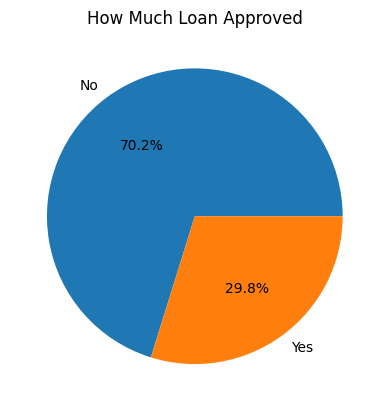

In [11]:
class_count = df['Loan_Approved'].value_counts()

plt.pie(class_count, labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('How Much Loan Approved')
plt.show()

[Text(0, 0, '621'), Text(0, 0, '379')]

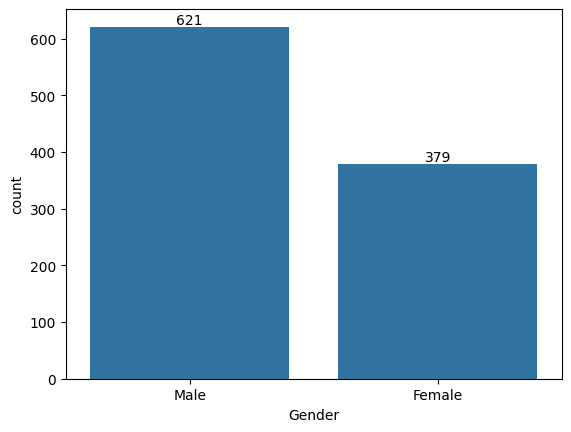

In [12]:
import seaborn as sns
gender_count = df['Gender'].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

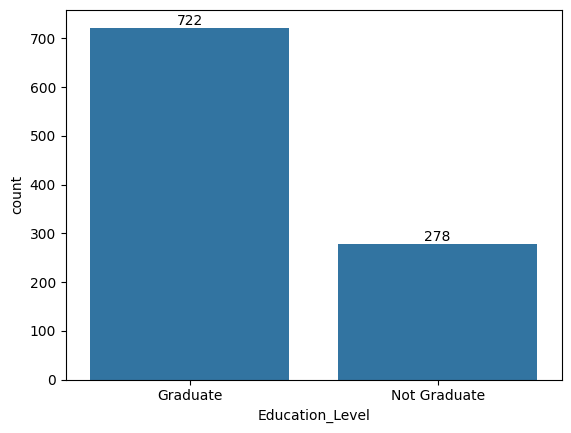

In [13]:
edu_counts = df['Education_Level'].value_counts()
ax = sns.barplot(edu_counts)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

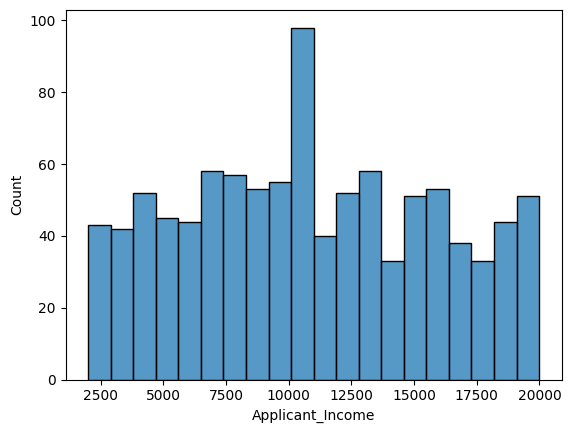

In [14]:
sns.histplot(
    data =df,
    x='Applicant_Income',
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

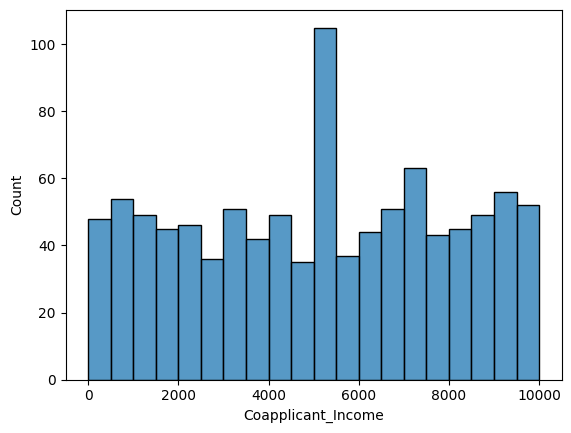

In [15]:
sns.histplot(df,
            x='Coapplicant_Income',
            bins=20)


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

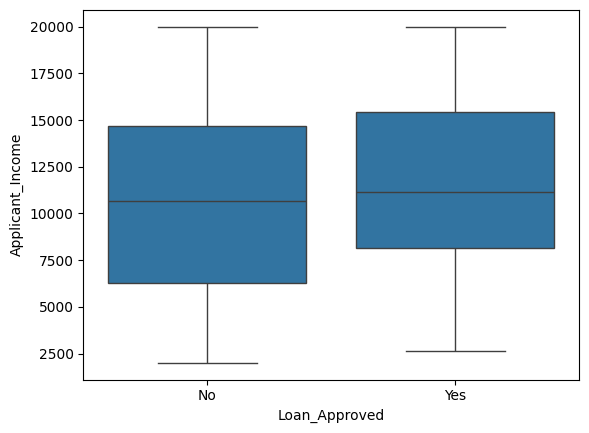

In [16]:
# Outliers Box Plot

sns.boxplot(
    data = df,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

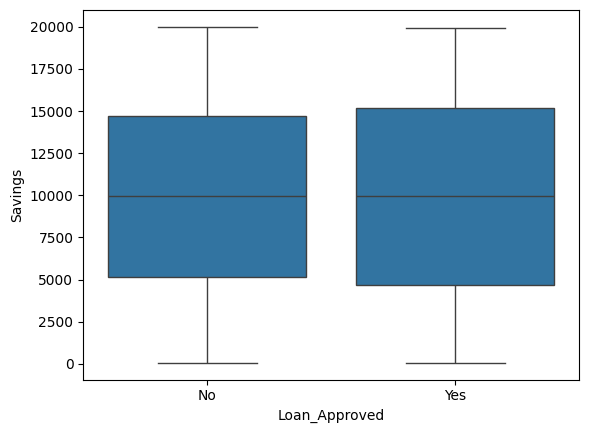

In [17]:
sns.boxplot(data = df, x='Loan_Approved', y = 'Savings')

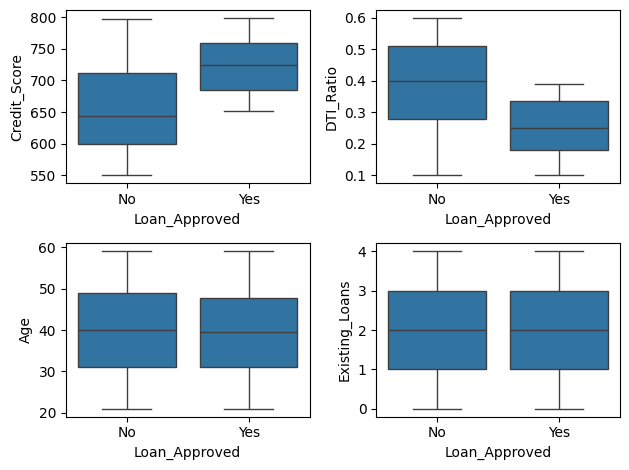

In [18]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data = df, x='Loan_Approved', y = 'Credit_Score')
sns.boxplot(ax=axes[0,1], data = df, x='Loan_Approved', y = 'DTI_Ratio')
sns.boxplot(ax=axes[1,0], data = df, x='Loan_Approved', y = 'Age')
sns.boxplot(ax=axes[1,1], data = df, x='Loan_Approved', y = 'Existing_Loans')

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

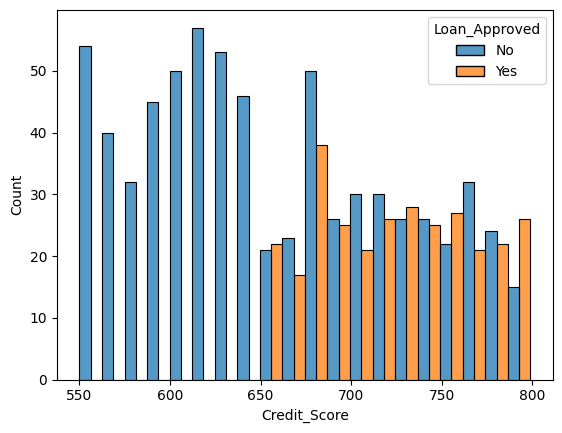

In [19]:
sns.histplot(df, x='Credit_Score', bins=20, hue='Loan_Approved', multiple='dodge')

In [20]:
# Drope Applicant ID
df = df.drop('Applicant_ID', axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encodeing

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [22]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding convert into 0 and 1 in the same column
le = LabelEncoder()
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])
df.head(10)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
5,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,0,Male,Unemployed,0
6,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,0,Male,Private,0
7,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,0,Female,Private,0
8,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,0,Male,Private,0
9,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,0,Female,Government,1


In [23]:
# One Hot Encoding tranform a columns each categorys into a each new column

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
cols = ['Gender', 'Employer_Category', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Employment_Status']

encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [24]:
colum=ohe.get_feature_names_out(cols) # for getting new columns which generated by One Hot Encoding
colum

array(['Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed'],
      dtype=object)

In [25]:
df.head(10)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
0,17795.0,1387.000000,51.0,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,2860.0,2679.000000,46.0,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,7390.0,2106.000000,25.0,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,13964.0,8173.000000,40.0,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,13284.0,4223.000000,31.0,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,8265.0,4831.000000,53.0,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
6,18850.0,2768.000000,58.0,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7,6426.0,3186.000000,47.0,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8,16423.0,5082.455789,54.0,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
9,13363.0,2599.000000,35.0,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# Co-Relation of Heatmap

It is a visual representation of relationship between numericle variebles in datasets

Its shows corelations of coefficient (r) between two numericle variebles

range of corelations -1 to 1,

where 1 is perfect corelation, A increase so B increase

where -1 is perfect nagetive corelation, A increase so B decrease

where 0 in represents no relations 

In [26]:
num_colum = df.select_dtypes(include='number')
cor_matt = num_colum.corr()
cor_matt

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.010057,-0.083398,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.000863,0.005609,0.001419
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,-0.011431,-0.020148,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.013517,-0.010462,0.023114
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,0.009162,-0.025521,-0.006283,0.029865,0.037293,0.003100,-0.025661,-0.000167,-0.011743,-0.009866
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.011410,-0.043685,-0.044642,0.027343,-0.005785,-0.032278,0.024082,-0.034611,0.079136,0.000396
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.056176,-0.030142,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.016627,-0.035896,-0.008344
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,0.018010,-0.025228,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.004462,0.042772,-0.012356
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,-0.014850,-0.020907,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.031658,-0.043904,0.022318
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,-0.004131,-0.009133,0.032558,-0.012217,-0.028948,0.005438,0.016833,0.022435,0.000668,0.006304
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.018450,0.031112,0.040406,-0.050975,-0.007120,0.020061,0.007975,-0.019882,0.000119,-0.041632
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,0.004683,-0.006788,-0.006119,-0.000930,0.032498,0.040206,-0.050076,-0.003266,-0.072972,-0.007407


In [27]:
num_colum.corr()['Loan_Approved'].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

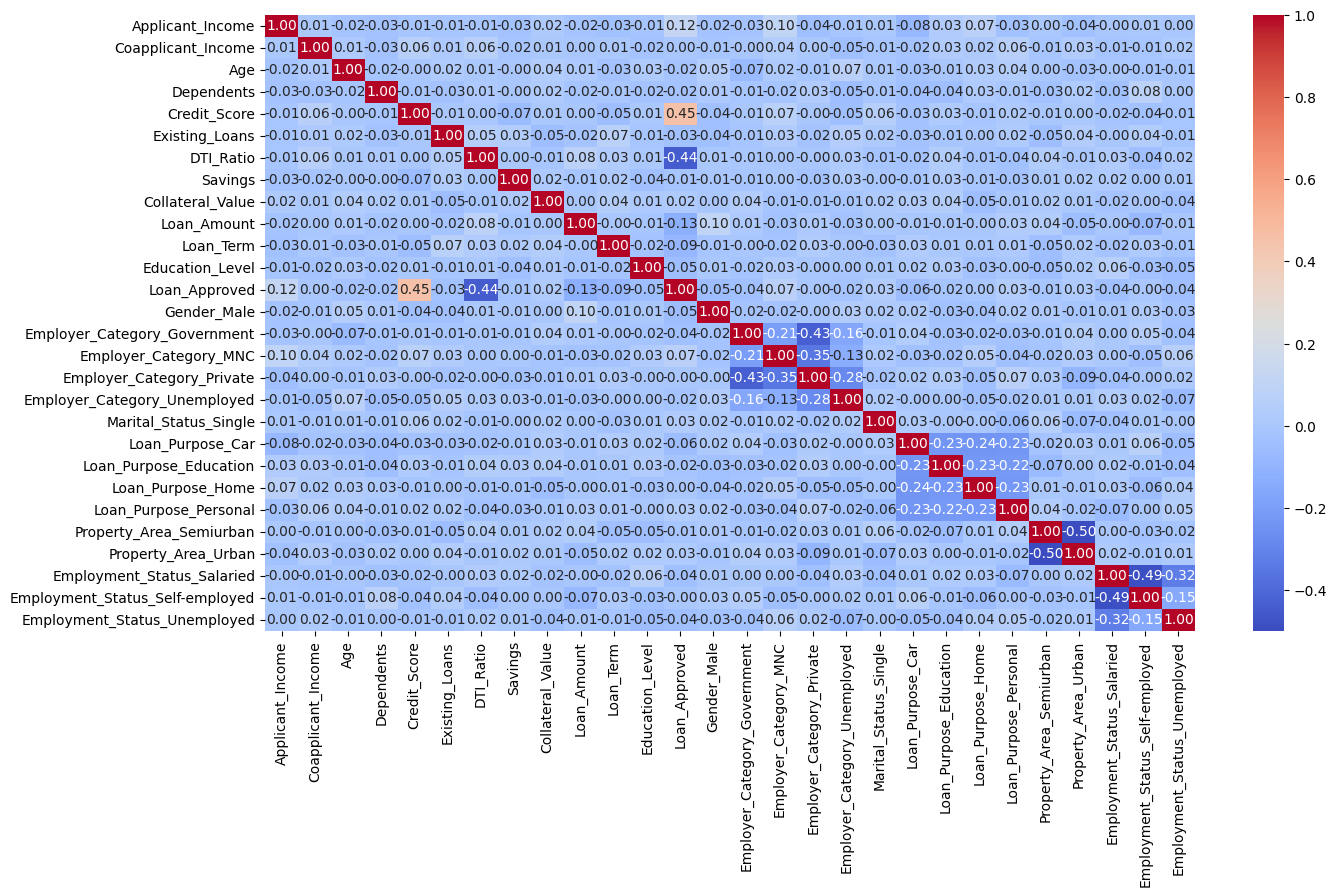

In [28]:
plt.figure(figsize=(15,8))
sns.heatmap(
    cor_matt,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

# Train Test Split and Feature Scaling

In [29]:
X = df.drop('Loan_Approved', axis=1)
Y = df['Loan_Approved']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [30]:
x_train.head()


,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

x_train_scaler

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
         9.65591606e-01, -4.82354268e-01, -3.12079621e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -1.03563452e+00, -4.82354268e-01, -3.12079621e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -1.03563452e+00,  2.07316503e+00, -3.12079621e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -1.03563452e+00, -4.82354268e-01,  3.20431048e+00]])

# Train and Evaluate Model

In [32]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train_scaler, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
x_test_scaler

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -1.03563452,
        -0.48235427,  3.20431048],
       [ 1.00971366,  0.58995935,  0.18392964, ...,  0.96559161,
        -0.48235427, -0.31207962],
       [-0.67557096, -0.54558674,  1.09887608, ...,  0.96559161,
        -0.48235427, -0.31207962],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -1.03563452,
        -0.48235427, -0.31207962],
       [-0.37650705, -0.97825874, -0.54802752, ...,  0.96559161,
        -0.48235427, -0.31207962],
       [-0.73647272, -1.24497436,  0.73289751, ..., -1.03563452,
         2.07316503, -0.31207962]])

In [34]:
log_pred = log_model.predict(x_test_scaler)
log_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

In [35]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print('Logistic Regression')
print(f'Confusion {confusion_matrix(y_test, log_pred)}')
print(f'Accuracy {accuracy_score(y_test, log_pred)}')
print(f'Precision {precision_score(y_test, log_pred)}')
print(f'recall {recall_score(y_test, log_pred)}')
print(f'F1 Score {f1_score(y_test, log_pred)}')

Logistic Regression
Confusion [[126  13]
 [ 14  47]]
Accuracy 0.865
Precision 0.7833333333333333
recall 0.7704918032786885
F1 Score 0.7768595041322314


# KNN Model

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaler, y_train)

y_pred = knn_model.predict(x_test_scaler)


print('KNN')
print(f'Confusion {confusion_matrix(y_test, y_pred)}')
print(f'Accuracy {accuracy_score(y_test, y_pred)}')
print(f'Precision {precision_score(y_test, y_pred)}')
print(f'recall {recall_score(y_test, y_pred)}')
print(f'F1 Score {f1_score(y_test, y_pred)}')

KNN
Confusion [[120  19]
 [ 29  32]]
Accuracy 0.76
Precision 0.6274509803921569
recall 0.5245901639344263
F1 Score 0.5714285714285714


In [37]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaler, y_train)

y_pred = nb_model.predict(x_test_scaler)

print('Naive Bayes')
print(f'Confusion {confusion_matrix(y_test, y_pred)}')
print(f'Accuracy {accuracy_score(y_test, y_pred)}')
print(f'Precision {precision_score(y_test, y_pred)}')
print(f'recall {recall_score(y_test, y_pred)}')
print(f'F1 Score {f1_score(y_test, y_pred)}')

Naive Bayes
Confusion [[128  11]
 [ 16  45]]
Accuracy 0.865
Precision 0.8035714285714286
recall 0.7377049180327869
F1 Score 0.7692307692307693


# Bast Model as per now prediction is Naive bayes

# Feature Engenearing

In [38]:
# Add or Train Features

df['DTI_Ratio_sq'] = df['DTI_Ratio'] ** 2
df['Credit_Score_sq'] = df['Credit_Score'] ** 2

X = df.drop(columns=['Loan_Approved', 'Credit_Score', 'DTI_Ratio'])
Y = df['Loan_Approved']

# Train test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#Scaling
scaler = StandardScaler()

x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

In [39]:
log_model = LogisticRegression()
log_model.fit(x_train_scaler, y_train)

y_pred = log_model.predict(x_test_scaler)

print('Logistic Regression')
print(f'Confusion {confusion_matrix(y_test, y_pred)}')
print(f'Accuracy {accuracy_score(y_test, y_pred)}')
print(f'Precision {precision_score(y_test, y_pred)}')
print(f'recall {recall_score(y_test, y_pred)}')
print(f'F1 Score {f1_score(y_test, y_pred)}')

Logistic Regression
Confusion [[126  13]
 [ 12  49]]
Accuracy 0.875
Precision 0.7903225806451613
recall 0.8032786885245902
F1 Score 0.7967479674796748


In [40]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaler, y_train)

y_pred = knn_model.predict(x_test_scaler)


print('KNN')
print(f'Confusion {confusion_matrix(y_test, y_pred)}')
print(f'Accuracy {accuracy_score(y_test, y_pred)}')
print(f'Precision {precision_score(y_test, y_pred)}')
print(f'recall {recall_score(y_test, y_pred)}')
print(f'F1 Score {f1_score(y_test, y_pred)}')

KNN
Confusion [[120  19]
 [ 30  31]]
Accuracy 0.755
Precision 0.62
recall 0.5081967213114754
F1 Score 0.5585585585585585


In [41]:
# nb_model = GaussianNB()
# nb_model.fit(x_train_scaler, y_train)

# y_pred = nb_model.predict(x_test_scaler)

# print('Naive Bayes')
# print(f'Confusion {confusion_matrix(y_test, y_pred)}')
# print(f'Accuracy {accuracy_score(y_test, y_pred)}')
# print(f'Precision {precision_score(y_test, y_pred)}')
# print(f'recall {recall_score(y_test, y_pred)}')
# print(f'F1 Score {f1_score(y_test, y_pred)}')


# After Featur Engenearing Evaluation got down or not good so without feature Engenearing Naive bayes is performing good compairing to others

In [45]:
import pickle

pickle.dump(nb_model, open("nb_model.pkl", "wb"))
pickle.dump(log_model, open("log_model.pkl", "wb"))
pickle.dump(knn_model, open("knn_model.pkl", "wb"))

In [43]:
pickle.dump(ohe, open("encoder.pkl", "wb"))
pickle.dump(le, open("label.pkl", "wb"))